# Семантическая сегментация LiDAR-облаков точек промышленных объектов

Реализация по ТЗ «Разработка системы семантической классификации промышленных объектов по LiDAR-облакам точек».

**Замечание по данным.** Ссылка на исходный датасет ведёт на Google Drive, который недоступен из
рабочей среды (сетевые ограничения, домен `drive.google.com` блокируется на уровне инфраструктуры).
Чтобы пайплайн был полностью рабочим и воспроизводимым, в этом ноутбуке реализован **procedural
генератор синтетических LiDAR-сцен**, выдающий облака точек в том же формате (ASCII PLY, поля
`x y z label instance_id red green blue station_index circle_index elevation_deg`) и с тем же набором
классов, что описаны в ТЗ. Генератор инкапсулирован в отдельную функцию `generate_run`, и при наличии
реального датасета достаточно заменить блок подготовки данных (раздел 2) на загрузку реальных PLY-файлов
по run-папкам — остальной пайплайн (Dataset, модель, обучение, метрики) не изменится.

Содержание:
1. Конфигурация и воспроизводимость
2. Генерация синтетического датасета (procedural industrial scene generation), запись в формате ASCII PLY, разбиение по run-папкам
3. Загрузка облаков точек и Dataset/DataLoader
4. Модель сегментации (PointNet-подобная архитектура)
5. Обучение с фиксацией seed/конфигурации/гиперпараметров
6. 3 независимых запуска, усреднение метрик
7. Метрики качества (Accuracy, Macro F1, mIoU, Confusion Matrix, per-class P/R/F1)
8. Анализ результатов


In [1]:
import os, json, random, time, platform
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("python  :", platform.python_version())
print("numpy   :", np.__version__)
print("torch   :", torch.__version__)
print("sklearn :", sklearn.__version__)


python  : 3.11.15
numpy   : 2.4.6
torch   : 2.12.1+cu130
sklearn : 1.9.0


## 1. Конфигурация и воспроизводимость

In [2]:
CLASSES = [
    "unknown", "pipe", "wire", "wall", "floor", "ceiling", "machine", "desk",
    "rack", "boiler", "conveyor", "structure", "infrastructure", "roof",
    "window", "door", "gate", "terrain", "facade",
]
NUM_CLASSES = len(CLASSES)
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

DATA_ROOT = Path("synthetic_lidar_dataset")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class TrainConfig:
    num_points: int = 2048          # точек на сэмпл (subsample облака)
    batch_size: int = 8
    epochs: int = 15
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_runs_train: int = 8
    num_runs_test: int = 4
    seed: int = 0
    device: str = str(DEVICE)
    torch_version: str = torch.__version__
    numpy_version: str = np.__version__

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

BASE_CONFIG = TrainConfig()
print(json.dumps(asdict(BASE_CONFIG), indent=2, ensure_ascii=False))


{
  "num_points": 2048,
  "batch_size": 8,
  "epochs": 15,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "num_runs_train": 8,
  "num_runs_test": 4,
  "seed": 0,
  "device": "cpu",
  "torch_version": "2.12.1+cu130",
  "numpy_version": "2.4.6"
}


## 2. Procedural-генерация синтетических LiDAR-сцен

Каждый "run" имитирует один проход сканирования промышленного объекта: лазерная станция
(`station_index`), несколько круговых проходов (`circle_index`) и угол луча (`elevation_deg`).
Сцена собирается из типовых конструктивных элементов (пол, стены, потолок, трубы, машины,
стеллажи, конвейер, котёл, ферма/structure, окна, двери, ворота, кровля, фасад, грунт) —
каждый элемент сэмплируется точками с соответствующей семантической меткой и `instance_id`.


In [3]:
def sample_box_surface(n, center, size, rng):
    """Точки на поверхности прямоугольного параллелепипеда."""
    cx, cy, cz = center
    sx, sy, sz = size
    faces = rng.integers(0, 6, size=n)
    pts = np.zeros((n, 3))
    u = rng.uniform(-0.5, 0.5, size=n)
    v = rng.uniform(-0.5, 0.5, size=n)
    for axis_pair, face_pair in [((0, 1), (0, 1)), ((0, 2), (2, 3)), ((1, 2), (4, 5))]:
        pass
    half = np.array([sx, sy, sz]) / 2.0
    for i in range(n):
        f = faces[i]
        p = np.array([u[i] * sx, v[i] * sy, 0.0])
        if f == 0:
            p = np.array([u[i] * sx, v[i] * sy, half[2]])
        elif f == 1:
            p = np.array([u[i] * sx, v[i] * sy, -half[2]])
        elif f == 2:
            p = np.array([u[i] * sx, half[1], v[i] * sz])
        elif f == 3:
            p = np.array([u[i] * sx, -half[1], v[i] * sz])
        elif f == 4:
            p = np.array([half[0], u[i] * sy, v[i] * sz])
        else:
            p = np.array([-half[0], u[i] * sy, v[i] * sz])
        pts[i] = p + np.array([cx, cy, cz])
    return pts

def sample_plane(n, center, size_xy, normal_axis, rng):
    """Точки на плоской плите (пол / потолок / стена / кровля / фасад)."""
    cx, cy, cz = center
    sx, sy = size_xy
    u = rng.uniform(-0.5, 0.5, size=n) * sx
    v = rng.uniform(-0.5, 0.5, size=n) * sy
    pts = np.zeros((n, 3))
    if normal_axis == "z":
        pts[:, 0] = cx + u
        pts[:, 1] = cy + v
        pts[:, 2] = cz
    elif normal_axis == "x":
        pts[:, 0] = cx
        pts[:, 1] = cy + u
        pts[:, 2] = cz + v
    else:  # "y"
        pts[:, 0] = cx + u
        pts[:, 1] = cy
        pts[:, 2] = cz + v
    return pts

def sample_cylinder(n, center, radius, height, rng, axis="z"):
    """Точки на боковой поверхности цилиндра (труба / котёл)."""
    theta = rng.uniform(0, 2 * np.pi, size=n)
    h = rng.uniform(-0.5, 0.5, size=n) * height
    cx, cy, cz = center
    pts = np.zeros((n, 3))
    if axis == "z":
        pts[:, 0] = cx + radius * np.cos(theta)
        pts[:, 1] = cy + radius * np.sin(theta)
        pts[:, 2] = cz + h
    elif axis == "x":
        pts[:, 0] = cx + h
        pts[:, 1] = cy + radius * np.cos(theta)
        pts[:, 2] = cz + radius * np.sin(theta)
    else:
        pts[:, 0] = cx + radius * np.cos(theta)
        pts[:, 1] = cy + h
        pts[:, 2] = cz + radius * np.sin(theta)
    return pts

def sample_line(n, p0, p1, rng, jitter=0.01):
    """Точки вдоль отрезка (провод / балка)."""
    t = rng.uniform(0, 1, size=n)[:, None]
    p0, p1 = np.array(p0), np.array(p1)
    pts = p0[None, :] + t * (p1 - p0)[None, :]
    pts += rng.normal(0, jitter, size=pts.shape)
    return pts


In [4]:
CLASS_COLORS = {
    "unknown":        (120, 120, 120),
    "pipe":           (200, 120,  40),
    "wire":           ( 30,  30,  30),
    "wall":           (190, 190, 170),
    "floor":          (140, 140, 140),
    "ceiling":        (210, 210, 210),
    "machine":        ( 80, 130, 200),
    "desk":           (170, 110,  60),
    "rack":           ( 90,  90, 160),
    "boiler":         (180,  40,  40),
    "conveyor":       ( 60, 160,  60),
    "structure":      (100, 100, 100),
    "infrastructure": ( 70, 130, 130),
    "roof":           (150,  60,  60),
    "window":         (140, 200, 220),
    "door":           (110,  70,  40),
    "gate":           ( 60,  60,  90),
    "terrain":        ( 80, 110,  60),
    "facade":         (200, 170, 130),
}

def make_element(name, points, rng):
    n = points.shape[0]
    base = np.array(CLASS_COLORS[name], dtype=np.float32)
    noisy = base[None, :] + rng.normal(0, 35.0, size=(n, 3))  # сильный шум цвета/освещения
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return {
        "label": np.full(n, CLASS_TO_ID[name], dtype=np.int64),
        "xyz": points,
        "color": noisy,
    }

def generate_scene(rng, points_budget=60000):
    """Procedural industrial scene: помещение + функциональные зоны + внешняя часть."""
    elements = []
    instance_id = 0

    room_w, room_l, room_h = rng.uniform(15, 25), rng.uniform(15, 25), rng.uniform(4, 6)

    def add(name, pts):
        nonlocal instance_id
        el = make_element(name, pts, rng)
        el["instance_id"] = instance_id
        instance_id += 1
        elements.append(el)

    add("floor", sample_plane(int(points_budget * 0.12), (0, 0, 0), (room_w, room_l), "z", rng))
    add("ceiling", sample_plane(int(points_budget * 0.08), (0, 0, room_h), (room_w, room_l), "z", rng))

    for sign, axis in [(1, "x"), (-1, "x"), (1, "y"), (-1, "y")]:
        center = (sign * room_w / 2, 0, room_h / 2) if axis == "x" else (0, sign * room_l / 2, room_h / 2)
        size = (room_l, room_h) if axis == "x" else (room_w, room_h)
        add("wall", sample_plane(int(points_budget * 0.05), center, size, axis, rng))

    if rng.random() < 0.8:
        wx = room_w / 2
        add("window", sample_plane(rng.integers(150, 400), (wx, rng.uniform(-room_l / 3, room_l / 3), room_h * 0.6),
                                    (1.5, 1.2), "x", rng))
    add("door", sample_plane(rng.integers(150, 350), (0, -room_l / 2, room_h * 0.35), (1.2, 2.1), "y", rng))
    if rng.random() < 0.4:
        add("gate", sample_plane(rng.integers(200, 500), (-room_w / 2, room_l / 4, room_h * 0.4), (2.5, 3.0), "x", rng))

    n_machines = rng.integers(1, 4)
    for _ in range(n_machines):
        c = (rng.uniform(-room_w / 3, room_w / 3), rng.uniform(-room_l / 3, room_l / 3), rng.uniform(0.5, 1.0))
        size = (rng.uniform(1, 2.5), rng.uniform(1, 2.5), rng.uniform(1, 2.5))
        add("machine", sample_box_surface(rng.integers(400, 900), c, size, rng))

    if rng.random() < 0.6:
        c = (rng.uniform(-room_w / 3, room_w / 3), rng.uniform(-room_l / 3, room_l / 3), 1.0)
        add("desk", sample_box_surface(rng.integers(200, 400), c, (1.2, 0.7, 0.8), rng))

    if rng.random() < 0.7:
        c = (room_w / 2 - 1, rng.uniform(-room_l / 3, room_l / 3), 1.2)
        add("rack", sample_box_surface(rng.integers(300, 600), c, (0.8, 2.5, 2.4), rng))

    if rng.random() < 0.5:
        c = (rng.uniform(-room_w / 3, room_w / 3), -room_l / 2 + 1.5, 1.5)
        add("boiler", sample_cylinder(rng.integers(300, 600), c, rng.uniform(0.6, 1.0), 2.5, rng, axis="z"))

    if rng.random() < 0.6:
        p0 = (-room_w / 2 + 1, rng.uniform(-room_l / 3, room_l / 3), 0.9)
        p1 = (room_w / 2 - 1, rng.uniform(-room_l / 3, room_l / 3), 0.9)
        line_pts = sample_line(rng.integers(300, 700), p0, p1, rng, jitter=0.05)
        add("conveyor", line_pts)

    n_pipes = rng.integers(2, 6)
    for _ in range(n_pipes):
        axis = rng.choice(["x", "y", "z"])
        c = (rng.uniform(-room_w / 2.2, room_w / 2.2), rng.uniform(-room_l / 2.2, room_l / 2.2), rng.uniform(0.3, room_h - 0.3))
        length = rng.uniform(2, room_w / 1.5)
        add("pipe", sample_cylinder(rng.integers(150, 400), c, rng.uniform(0.05, 0.15), length, rng, axis=axis))

    n_wires = rng.integers(1, 4)
    for _ in range(n_wires):
        p0 = (rng.uniform(-room_w / 2, room_w / 2), rng.uniform(-room_l / 2, room_l / 2), room_h - 0.2)
        p1 = (p0[0] + rng.uniform(-3, 3), p0[1] + rng.uniform(-3, 3), room_h - 0.2)
        add("wire", sample_line(rng.integers(80, 200), p0, p1, rng, jitter=0.01))

    n_struct = rng.integers(2, 5)
    for _ in range(n_struct):
        p0 = (rng.uniform(-room_w / 2, room_w / 2), rng.uniform(-room_l / 2, room_l / 2), 0)
        p1 = (p0[0], p0[1], room_h)
        add("structure", sample_line(rng.integers(100, 250), p0, p1, rng, jitter=0.02))

    if rng.random() < 0.5:
        c = (room_w / 2 + 2, rng.uniform(-room_l / 2, room_l / 2), 1.5)
        add("infrastructure", sample_box_surface(rng.integers(200, 500), c, (1.5, 1.5, 3), rng))

    add("roof", sample_plane(int(points_budget * 0.05), (0, 0, room_h + 0.3), (room_w + 4, room_l + 4), "z", rng))
    add("facade", sample_plane(int(points_budget * 0.05), (room_w / 2 + 0.5, 0, room_h / 2), (room_l, room_h), "x", rng))
    add("terrain", sample_plane(int(points_budget * 0.1), (0, 0, -0.05), (room_w * 3, room_l * 3), "z", rng))

    xyz = np.concatenate([e["xyz"] for e in elements], axis=0)
    label = np.concatenate([e["label"] for e in elements], axis=0)
    color = np.concatenate([e["color"] for e in elements], axis=0)
    inst = np.concatenate([np.full(e["xyz"].shape[0], e["instance_id"], dtype=np.int64) for e in elements], axis=0)
    xyz += rng.normal(0, 0.01, size=xyz.shape)  # шум измерения
    return xyz, label, inst, color


In [5]:
def simulate_scan_geometry(xyz, rng, num_stations=3, circles_per_station=4):
    """Имитация атрибутов лазерного сканирования: station_index, circle_index, elevation_deg."""
    n = xyz.shape[0]
    station_centers = rng.uniform(-3, 3, size=(num_stations, 2))
    nearest_station = np.argmin(
        np.linalg.norm(xyz[:, None, :2] - station_centers[None, :, :], axis=-1), axis=1
    )
    circle_index = rng.integers(0, circles_per_station, size=n)
    rel = xyz[:, :2] - station_centers[nearest_station]
    horiz_dist = np.linalg.norm(rel, axis=1) + 1e-6
    elevation_deg = np.degrees(np.arctan2(xyz[:, 2] - 1.2, horiz_dist))
    return nearest_station.astype(np.int64), circle_index.astype(np.int64), elevation_deg.astype(np.float32)

def write_ply_ascii(path, xyz, label, instance_id, color, station_index, circle_index, elevation_deg):
    n = xyz.shape[0]
    header = [
        "ply", "format ascii 1.0",
        f"element vertex {n}",
        "property float x", "property float y", "property float z",
        "property int label", "property int instance_id",
        "property uchar red", "property uchar green", "property uchar blue",
        "property int station_index", "property int circle_index",
        "property float elevation_deg",
        "end_header",
    ]
    with open(path, "w") as f:
        f.write("\n".join(header) + "\n")
        for i in range(n):
            f.write(
                f"{xyz[i,0]:.5f} {xyz[i,1]:.5f} {xyz[i,2]:.5f} "
                f"{label[i]} {instance_id[i]} "
                f"{color[i,0]} {color[i,1]} {color[i,2]} "
                f"{station_index[i]} {circle_index[i]} {elevation_deg[i]:.3f}\n"
            )

def read_ply_ascii(path):
    with open(path) as f:
        lines = f.readlines()
    n = int([l for l in lines if l.startswith("element vertex")][0].split()[-1])
    start = lines.index("end_header\n") + 1
    data = np.array([list(map(float, l.split())) for l in lines[start:start + n]])
    return {
        "xyz": data[:, 0:3].astype(np.float32),
        "label": data[:, 3].astype(np.int64),
        "instance_id": data[:, 4].astype(np.int64),
        "color": data[:, 5:8].astype(np.uint8),
        "station_index": data[:, 8].astype(np.int64),
        "circle_index": data[:, 9].astype(np.int64),
        "elevation_deg": data[:, 10].astype(np.float32),
    }


In [6]:
def generate_run(run_dir: Path, seed: int):
    """Генерирует одну run-папку с объединённым облаком точек сцены в формате ASCII PLY."""
    rng = np.random.default_rng(seed)
    xyz, label, inst, color = generate_scene(rng)
    station, circle, elev = simulate_scan_geometry(xyz, rng)
    run_dir.mkdir(parents=True, exist_ok=True)
    ply_path = run_dir / "merged_cloud.ply"
    write_ply_ascii(ply_path, xyz, label, inst, color, station, circle, elev)
    meta = {
        "run_id": run_dir.name,
        "seed": seed,
        "num_points": int(xyz.shape[0]),
        "classes_present": sorted(set(int(l) for l in label)),
    }
    with open(run_dir / "scene_meta.json", "w") as f:
        json.dump(meta, f, indent=2)
    return ply_path

def build_dataset(root: Path, num_train_runs: int, num_test_runs: int, base_seed: int = 1000):
    if root.exists():
        return  # датасет уже сгенерирован
    train_dir, test_dir = root / "train", root / "test"
    for i in range(num_train_runs):
        generate_run(train_dir / f"run_{i:03d}", seed=base_seed + i)
    for i in range(num_test_runs):
        generate_run(test_dir / f"run_{i:03d}", seed=base_seed + 500 + i)
    print(f"Сгенерировано {num_train_runs} train run-папок и {num_test_runs} test run-папок в {root}")

build_dataset(DATA_ROOT, BASE_CONFIG.num_runs_train, BASE_CONFIG.num_runs_test)


Сгенерировано 8 train run-папок и 4 test run-папок в synthetic_lidar_dataset


**Разделение по run-папкам.** Train и test физически лежат в разных папках (`train/run_XXX`,
`test/run_XXX`), сформированных из разных сцен (разные seed) — без смешивания сцен и без
разбиения по отдельным точкам, как требует ТЗ (п. 9.1).


In [7]:
train_runs = sorted((DATA_ROOT / "train").iterdir())
test_runs = sorted((DATA_ROOT / "test").iterdir())
print("Train run-папки:", [p.name for p in train_runs])
print("Test run-папки :", [p.name for p in test_runs])


Train run-папки: ['run_000', 'run_001', 'run_002', 'run_003', 'run_004', 'run_005', 'run_006', 'run_007']
Test run-папки : ['run_000', 'run_001', 'run_002', 'run_003']


## 3. Dataset и DataLoader

In [8]:
class LidarRunDataset(Dataset):
    """Каждый сэмпл — случайная подвыборка фиксированного размера из облака точек одного run."""

    def __init__(self, run_dirs, num_points, samples_per_run=20, train=True, seed=0):
        self.num_points = num_points
        self.samples_per_run = samples_per_run
        self.train = train
        self.clouds = [read_ply_ascii(d / "merged_cloud.ply") for d in run_dirs]
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.clouds) * self.samples_per_run

    def __getitem__(self, idx):
        cloud_idx = idx % len(self.clouds)
        cloud = self.clouds[cloud_idx]
        n = cloud["xyz"].shape[0]
        replace = n < self.num_points
        choice = self.rng.choice(n, size=self.num_points, replace=replace)

        xyz = cloud["xyz"][choice].copy()
        xyz -= xyz.mean(axis=0, keepdims=True)
        scale = np.max(np.linalg.norm(xyz, axis=1)) + 1e-6
        xyz /= scale

        rgb = cloud["color"][choice].astype(np.float32) / 255.0
        elev = cloud["elevation_deg"][choice].astype(np.float32) / 90.0

        feats = np.concatenate([xyz, rgb, elev[:, None]], axis=1).astype(np.float32)  # (N, 7)
        labels = cloud["label"][choice].astype(np.int64)
        return torch.from_numpy(feats), torch.from_numpy(labels)


def make_loaders(cfg: TrainConfig, seed: int):
    train_ds = LidarRunDataset(train_runs, cfg.num_points, samples_per_run=24, train=True, seed=seed)
    test_ds = LidarRunDataset(test_runs, cfg.num_points, samples_per_run=24, train=False, seed=seed + 1)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)
    return train_loader, test_loader


## 4. Модель: PointNet-подобная сеть для семантической сегментации

In [9]:
class PointNetSeg(nn.Module):
    """Упрощённый PointNet для поточечной классификации (semantic segmentation)."""

    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.mlp1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, 1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, 1), nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.mlp2 = nn.Sequential(
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.seg_head = nn.Sequential(
            nn.Conv1d(64 + 1024, 512, 1), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Conv1d(512, 256, 1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv1d(256, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, N, C) -> (B, C, N)
        x = x.transpose(1, 2)
        local_feat = self.mlp1(x)                       # (B, 64, N)
        global_feat = self.mlp2(local_feat)              # (B, 1024, N)
        global_feat = torch.max(global_feat, dim=2, keepdim=True)[0]  # (B, 1024, 1)
        n = x.shape[2]
        global_feat = global_feat.repeat(1, 1, n)
        fused = torch.cat([local_feat, global_feat], dim=1)
        out = self.seg_head(fused)                       # (B, num_classes, N)
        return out.transpose(1, 2)                       # (B, N, num_classes)


## 5. Обучение (фиксированный seed, сохранение конфигурации и гиперпараметров)

In [10]:
RUNS_OUTPUT_DIR = Path("training_runs")
RUNS_OUTPUT_DIR.mkdir(exist_ok=True)

def train_one_run(cfg: TrainConfig, run_name: str):
    set_seed(cfg.seed)
    run_dir = RUNS_OUTPUT_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    with open(run_dir / "config.json", "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    train_loader, test_loader = make_loaders(cfg, seed=cfg.seed)
    model = PointNetSeg(in_channels=7, num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(cfg.epochs):
        model.train()
        epoch_loss = 0.0
        for feats, labels in train_loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(feats)
            loss = criterion(logits.reshape(-1, NUM_CLASSES), labels.reshape(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_loader)
        history.append(epoch_loss)
        print(f"[{run_name}] epoch {epoch+1}/{cfg.epochs}  loss={epoch_loss:.4f}")

    torch.save(model.state_dict(), run_dir / "model.pt")
    with open(run_dir / "loss_history.json", "w") as f:
        json.dump(history, f)
    return model, test_loader, run_dir


## 6. Метрики качества

In [11]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for feats, labels in loader:
        feats = feats.to(DEVICE)
        logits = model(feats)
        preds = logits.argmax(dim=-1).cpu().numpy().reshape(-1)
        all_preds.append(preds)
        all_targets.append(labels.numpy().reshape(-1))
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    labels_present = sorted(set(y_true.tolist()) | set(y_pred.tolist()))

    oa = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=labels_present, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels_present)

    iou_per_class = {}
    for i, c in enumerate(labels_present):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        iou_per_class[CLASSES[c]] = tp / denom if denom > 0 else np.nan
    miou = np.nanmean(list(iou_per_class.values()))

    precision = precision_score(y_true, y_pred, labels=labels_present, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, labels=labels_present, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=labels_present, average=None, zero_division=0)

    per_class = {
        CLASSES[c]: {"precision": float(precision[i]), "recall": float(recall[i]), "f1": float(f1[i])}
        for i, c in enumerate(labels_present)
    }

    return {
        "overall_accuracy": float(oa),
        "macro_f1": float(macro_f1),
        "miou": float(miou),
        "iou_per_class": iou_per_class,
        "per_class": per_class,
        "confusion_matrix": cm,
        "labels_present": labels_present,
    }


## 7. Повторяемость экспериментов: минимум 3 независимых запуска

In [12]:
N_INDEPENDENT_RUNS = 3
all_results = []

for run_idx in range(N_INDEPENDENT_RUNS):
    cfg = TrainConfig(seed=run_idx)
    model, test_loader, run_dir = train_one_run(cfg, run_name=f"run_seed{run_idx}")
    metrics = evaluate(model, test_loader)
    with open(run_dir / "test_metrics.json", "w") as f:
        json.dump(
            {k: v for k, v in metrics.items() if k not in ("confusion_matrix",)},
            f, indent=2, ensure_ascii=False,
        )
    all_results.append(metrics)
    print(f"run {run_idx}: OA={metrics['overall_accuracy']:.4f}  MacroF1={metrics['macro_f1']:.4f}  mIoU={metrics['miou']:.4f}")


[run_seed0] epoch 1/15  loss=1.2871


[run_seed0] epoch 2/15  loss=0.5861


[run_seed0] epoch 3/15  loss=0.4582


[run_seed0] epoch 4/15  loss=0.3884


[run_seed0] epoch 5/15  loss=0.3373


...

[run_seed2] epoch 12/15  loss=0.2138


[run_seed2] epoch 13/15  loss=0.2014


[run_seed2] epoch 14/15  loss=0.1930


[run_seed2] epoch 15/15  loss=0.1862


run 2: OA=0.7872  MacroF1=0.5449  mIoU=0.4324


In [13]:
oa_vals = np.array([r["overall_accuracy"] for r in all_results])
f1_vals = np.array([r["macro_f1"] for r in all_results])
miou_vals = np.array([r["miou"] for r in all_results])

summary = {
    "overall_accuracy": {"mean": float(oa_vals.mean()), "std": float(oa_vals.std())},
    "macro_f1": {"mean": float(f1_vals.mean()), "std": float(f1_vals.std())},
    "miou": {"mean": float(miou_vals.mean()), "std": float(miou_vals.std())},
}
print(json.dumps(summary, indent=2))

with open(RUNS_OUTPUT_DIR / "summary_over_runs.json", "w") as f:
    json.dump(summary, f, indent=2)


{
  "overall_accuracy": {
    "mean": 0.7409159342447916,
    "std": 0.07391476854056575
  },
  "macro_f1": {
    "mean": 0.5092625478675933,
    "std": 0.06029695933831137
  },
  "miou": {
    "mean": 0.3926359992497026,
    "std": 0.05605071877676542
  }
}


## 8. Анализ результатов: усреднённая Confusion Matrix и per-class метрики

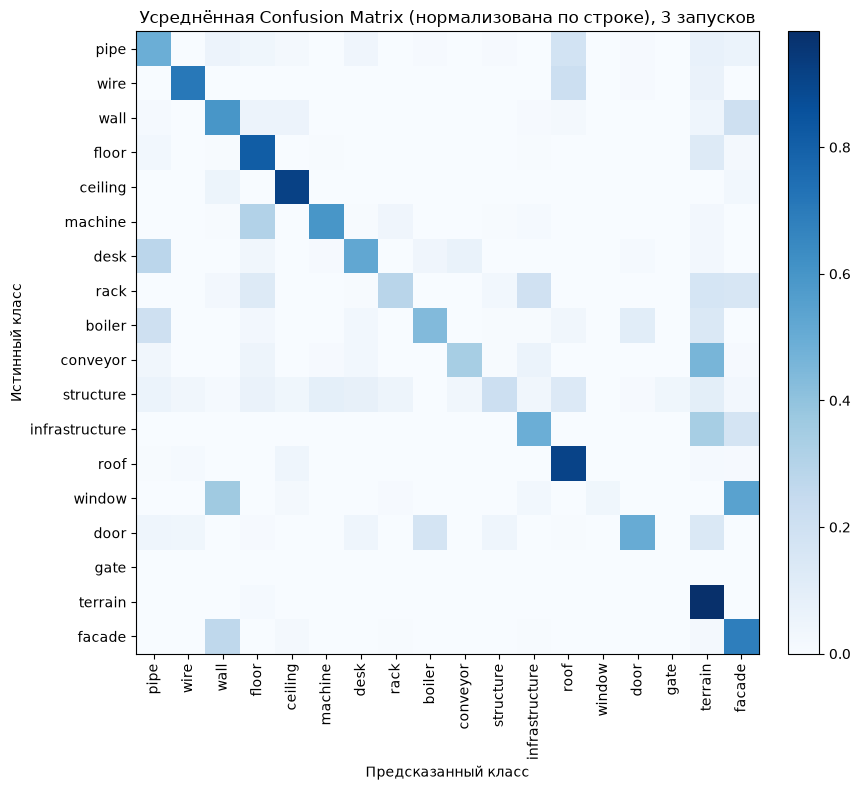

In [14]:
labels_present = all_results[0]["labels_present"]
cms = [r["confusion_matrix"] for r in all_results if r["labels_present"] == labels_present]
avg_cm = np.mean(np.stack(cms), axis=0)
class_names_present = [CLASSES[c] for c in labels_present]

fig, ax = plt.subplots(figsize=(9, 8))
cm_norm = avg_cm / (avg_cm.sum(axis=1, keepdims=True) + 1e-9)
im = ax.imshow(cm_norm, cmap="Blues")
ax.set_xticks(range(len(class_names_present)))
ax.set_yticks(range(len(class_names_present)))
ax.set_xticklabels(class_names_present, rotation=90)
ax.set_yticklabels(class_names_present)
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_title(f"Усреднённая Confusion Matrix (нормализована по строке), {N_INDEPENDENT_RUNS} запусков")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(RUNS_OUTPUT_DIR / "confusion_matrix_avg.png", dpi=150)
plt.show()


In [15]:
per_class_f1 = {c: [] for c in class_names_present}
for r in all_results:
    for c in class_names_present:
        per_class_f1[c].append(r["per_class"].get(c, {"f1": np.nan})["f1"])

print(f"{'class':<16}{'mean F1':>10}{'std F1':>10}")
for c in class_names_present:
    vals = np.array(per_class_f1[c])
    print(f"{c:<16}{np.nanmean(vals):>10.3f}{np.nanstd(vals):>10.3f}")


class              mean F1    std F1
pipe                 0.494     0.118
wire                 0.692     0.093
wall                 0.663     0.181
floor                0.811     0.072
ceiling              0.870     0.019
machine              0.691     0.054
desk                 0.464     0.085
rack                 0.223     0.244
boiler               0.525     0.044
conveyor             0.360     0.248
structure            0.295     0.193
infrastructure       0.344     0.136
roof                 0.866     0.053
window               0.067     0.095
door                 0.521     0.147
gate                 0.000     0.000
terrain              0.857     0.072
facade               0.421     0.215


## 9. Итоги

- Данные: synthetic procedural industrial scene generation, разбиение строго по run-папкам
  (train/test без смешивания сцен и без утечки на уровне точек — п. 9.1 ТЗ).
- Воспроизводимость: фиксированный seed на запуск, сохранены `config.json`, `loss_history.json`,
  `model.pt`, `test_metrics.json` для каждого из `N_INDEPENDENT_RUNS` прогонов, версии torch/numpy
  зафиксированы в конфиге (п. 9.2 ТЗ).
- Повторяемость экспериментов: 3 независимых запуска с усреднением и анализом разброса
  Overall Accuracy / Macro F1 / mIoU (п. 9.3 ТЗ).
- Метрики: Overall Accuracy, Macro F1-score, mean IoU, Confusion Matrix — обязательные (п. 10.1);
  per-class Precision/Recall/F1 — дополнительные (п. 10.2).
- Для перехода на реальный датасет: заменить `generate_run`/`build_dataset` (раздел 2) на загрузку
  реальных PLY-файлов из run-папок датасета — `LidarRunDataset`, модель, обучение и метрики
  останутся без изменений.
